# **Alura+**: Tipos de Visualización de Datos
---

## Análisis de los Microdatos de las pruebas **Saber11 (2018 - 2022)**

> Colombia (32 departamentos)
- Periodo
- Departamento
- Municipio
- Edad
- Situación económica
- Estrato del estudiante
- Puntajes (Matemáticas, Inglés, Ciencias Naturales, Lectura Crítica, Ciencias Sociales, Global)


### Importando las bibliotecas y cargando el archivo

In [ ]:
# Importando las bibliotecas para la manipulación y visualización de los datos
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import plotly.express as px

# Cargando el archivo de los microdatos en el ambiente a través de un dataframe
saber = pd.read_csv("https://caelum-online-public.s3.amazonaws.com/alura-mas/Saber11_2018-2022.csv")

saber.head()

,PERIODO,DEPARTAMENTO,MUNICIPIO,INSTITUCION,EDAD,FAMI_SITUACIONECONOMICA,FAMI_ESTRATOVIVIENDA,PUNT_MATEMATICAS,PUNT_INGLES,PUNT_C_NATURALES,PUNT_LECTURA_CRITICA,PUNT_SOCIALES_CIUDADANAS,PUNT_GLOBAL
0,2018,ATLANTICO,PIOJÓ,INSTITUCION EDUCATIVA NIÑO JESUS DE PRAGA,24.0,Peor,Estrato 1,30,42.0,39,40,30,177
1,2018,ANTIOQUIA,ARBOLETES,COLEGIO EL CARMELO,23.0,Igual,Estrato 1,40,41.0,40,43,36,199
2,2018,ATLANTICO,BARRANQUILLA,CENTRO EDUCATIVO SAN BERNARDO PARA ADULTOS,25.0,Igual,Estrato 2,34,38.0,41,38,30,180
3,2018,ATLANTICO,SOLEDAD,INSTITUCION EDUCATIVA FRANCISCO JOSE DE CALDAS,21.0,Igual,Estrato 1,54,44.0,47,51,53,253
4,2018,BOLIVAR,CARTAGENA DE INDIAS,INSTITUCION EDUCATIVA SANTA MARIA,23.0,Igual,Estrato 2,29,29.0,40,53,43,202


## Tipos de Visualización

Para escoger mejor el tipo de visualización de nuestros datos necesitamos preguntarnos primeramente **cómo** queremos representarlos y **qué** queremos informarle a nuestro público.

En la siguiente imagen, presentamos un diagrama con diversos tipos de **visualización de datos** (creado por [Andrew Abela](https://extremepresentation.com/wp-content/uploads/choosing-a-good-chart-09-1.pdf)) en el que es posible percibir que los gráficos más comúnes pueden ser dividos en **4 subgrupos**:

- Comparación
- Distribución
- Relación
- Composición

<img src="https://strapi.biuwer.com/uploads/biuwer_how_to_choose_the_right_chart_for_your_data_205f79394b.png" alt="inserir alt" height="720" width="900">

<font size=2>Fuente: Andrew Abela (Extreme Presentation/Biuwer)</font>

### <font color=#E6ae1d size=5>Comparación 📊</font>


---


Este es ampliamente utilizado cuando queremos **comparar diferentes valores y atributos** entre los datos, es decir, unos con otros.

El tipo puede variar dependiendo de los datos. Por ejemplo:

- ¿Nuestros datos poseen una variable temporal?
 - ¿Cuántos períodos de tiempo tenemos?
- ¿Cuántas variables y categorías nuestros datos presentan?

<font color=green> Visualizaciones más comunes: </font> Gráficos de columnas, barras y líneas.


#### Gráfico de Barras

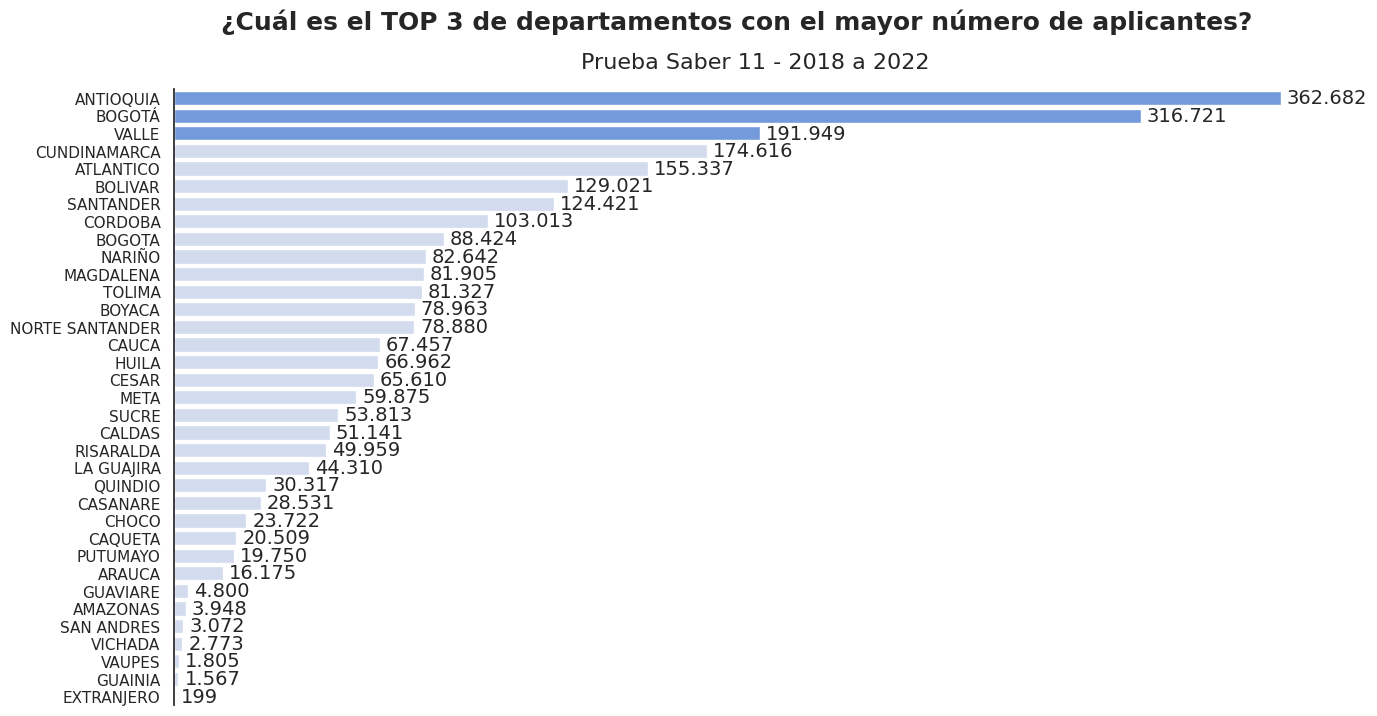

In [ ]:
#@title
## Configurando el gráfico con parámetros que potencializan la visualización de los datos

# Área de visualización y ocultar los bordes del gráfico excepto al lado izquierdo
plt.figure(figsize=(15, 8))
custom_params = {"axes.spines.right": False, "axes.spines.top": False,
                 "axes.spines.bottom": False}

# Tema más limpio para la visualización con los parámetros previamente descritos
sns.set_theme(context="notebook", style="white", rc=custom_params)

# Destacando el TOP 3 departamentos con mayor cantidad de aplicantes
departamentos = saber["DEPARTAMENTO"].value_counts().index
top_3 = departamentos[:3]
colores = ["#6495ed" if (estado in top_3) else "#cddbf3" for estado in departamentos]

# Plotando el gráfico de barras y ocultando los puntos del eje X
ax = sns.countplot(data = saber, y = "DEPARTAMENTO", order = saber["DEPARTAMENTO"].value_counts().index, palette = colores)
ax.set_xticklabels([])

# Añadiendo un título y subtítulo al gráfico y ocultando los labels de cada eje
plt.suptitle("¿Cuál es el TOP 3 de departamentos con el mayor número de aplicantes?", size = 18, weight='bold')
plt.title("Prueba Saber 11 - 2018 a 2022", fontsize = 16, pad = 15)
plt.ylabel("")
plt.xlabel("")

# Escribiendo los valores de cada barra (eje X) en el gráfico
for index, barra in enumerate(ax.patches):
  pos_x = barra.get_width()
  pos_y = barra.get_y() + barra.get_height() / 2
  offset = 2000
  cantidad = f'{pos_x:,.0f}'.replace(',','.')
  ax.text(x = pos_x + offset , y = pos_y, s = cantidad, va='center', fontsize=14)

<font color=green size=4> Observaciones e hipótesis: </font>

---

Podemos fácilmente observar la cantidad de aplicantes del saber 11 relativo a cada departamento en el período comprendido entre 2018 y 2022. Además de ello, podemos ver a **Antioquia, Bogotá y Valle** cómo el **TOP 3** departamentos con más aplicantes. Nótese que Bogotá es el distrito capital de Colombia y por esta razón está comprendido como departamento.

Sería interesante trazar un paralelo con la población de cada departamento o con el número de estudiantes en dichos departamentos a través de fuentes externas, como el DANE.

#### Gráfico de Columnas

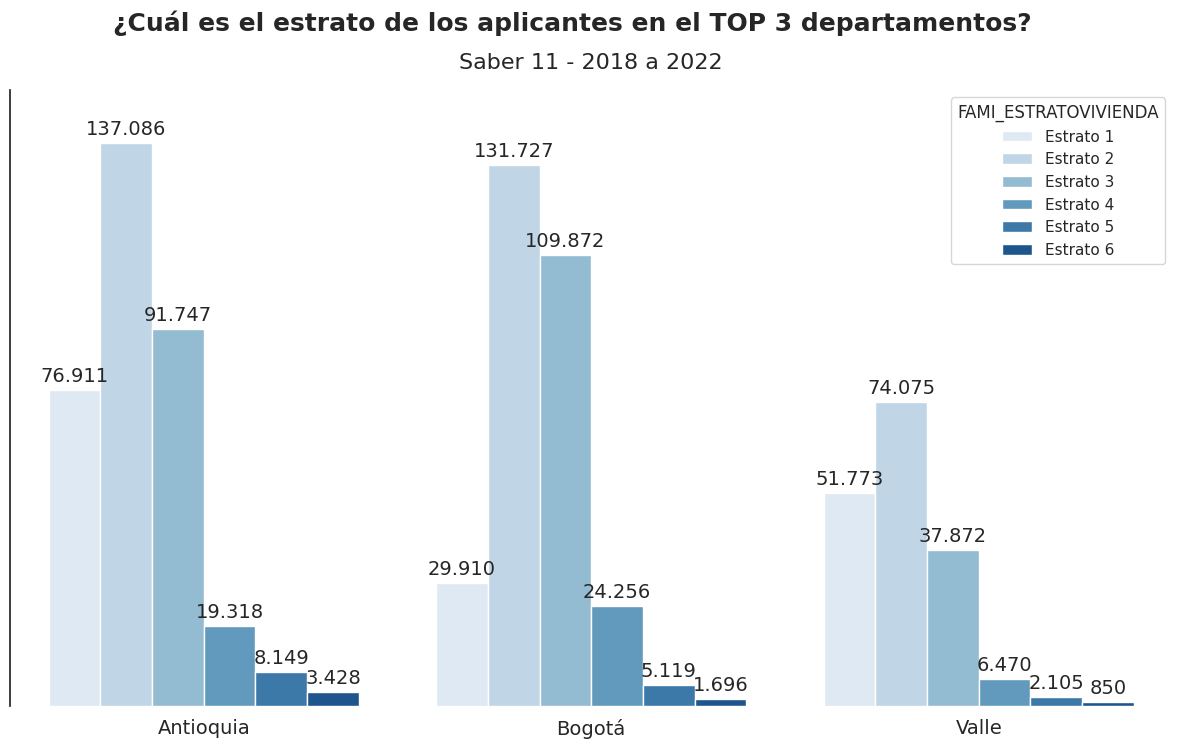

In [ ]:
#@title
## Configurando el gráfico con parámetros que potencializan la visualización de los datos

# Área de visualización y ocultar los bordes del gráfico excepto al lado izquierdo
plt.figure(figsize=(15, 8))
custom_params = {"axes.spines.right": False, "axes.spines.top": False,
                 "axes.spines.bottom": False}

# Tema más limpio para la visualización con los parámetros previamente descritos
sns.set_theme(context="notebook", style="white", rc=custom_params)

# Seleccionando apenas los 3 departamentos con el mayor número de aplicantes y eliminando
# los casos que presentan de manera inconclusiva el estrato ("Sin Estrato")
top_3 = ["ANTIOQUIA", "BOGOTÁ", "VALLE"]
saber_top3_estrato = saber[-(saber["FAMI_ESTRATOVIVIENDA"] == "Sin Estrato")].query("DEPARTAMENTO == @top_3")

# Plotando el gráfico de columnas, ocultando los puntos del eje Y y definiendo las
# variables categóricas del eje X (departamentos)
ax = sns.countplot(data = saber_top3_estrato.sort_values("DEPARTAMENTO"), x = "DEPARTAMENTO",
                   hue= "FAMI_ESTRATOVIVIENDA", hue_order = ["Estrato 1","Estrato 2",
                                                             "Estrato 3","Estrato 4",
                                                             "Estrato 5","Estrato 6",], palette = 'Blues')
ax.set_yticklabels([])
ax.set_xticklabels(["Antioquia", "Bogotá", "Valle"], fontsize = 14)

# Añadiendo título y subtítulo al gráfico y ocultando las etiquetas de cada eje
plt.suptitle("¿Cuál es el estrato de los aplicantes en el TOP 3 departamentos?", size = 18, weight='bold')
plt.title("Saber 11 - 2018 a 2022", fontsize = 16, pad = 15)
plt.ylabel("")
plt.xlabel("")

# Describiendo el límite mínimo y máximo del eje Y
plt.ylim(0, 150000)

# Escribiendo los valores de cada columna (eje Y) en el gráfico
for index, barra in enumerate(ax.patches):
  pos_x = barra.get_x() + barra.get_width() / 2
  pos_y = barra.get_height()
  offset = 2000
  cantidad = f'{pos_y:,.0f}'.replace(',','.')
  ax.text(x = pos_x, y = pos_y + offset, s = cantidad, ha='center', fontsize=14)

<font color=green size=4> Observaciones e Hipótesis: </font>

---

Tras presentar los departamentos de **Antioquia, Bogotá* y Valle** como el **TOP 3** de los departamentos con más aplicantes, es posible, a través del gráfico de columnas, verificar la cantidad de aplicantes de acuerdo con el estrato declarado en el formulario en cada departamento.

Podemos observar que los três departamentos poseen el **Estrato 2** como el **estrato al cual pertenecen** la mayoría de aplicantes. Por otra parte, en **Bogotá** se evidencia que los estratos 2 y 3 comprenden la mayoría de aplicantes (aproximadamente **43%** y **36%**, para los estratos 2 y 3 respectivamente). En Antioquia, el **Estrato 6** corresponde a aproximadamente el **1%** de los aplicantes, y en Bogotá y el Valle, corresponde a **< 1%** .

*Nótese que Bogotá es el distrito capital de Colombia y por esta razón está comprendido como departamento

#### Gráfico de líneas

In [ ]:
#@title
saber.PUNT_INGLES.isna().sum()

6236

In [ ]:
#@title
# Retirando los puntajes NaN del subset de Puntajes de Inglés
saber_ingles = saber.dropna(subset=["PUNT_INGLES"])

# Seleccionando las columnas relevantes para el análisis y tan solo los puntajes
# de las pruebas realizadas en Antioquia
columnas = ["PERIODO", "DEPARTAMENTO", "PUNT_INGLES"]
saber_ingles_antioquia = saber_ingles[columnas].query("DEPARTAMENTO == 'ANTIOQUIA'")

# Agregando los puntajes y calculando el promedio de la materia para el año
saber_ingles_antioquia = saber_ingles_antioquia.groupby(["PERIODO"]).aggregate("mean")

# Ajustando el DataFrame para presentar la variable PERIODO como columna y no como index
saber_ingles_antioquia = saber_ingles_antioquia.reset_index()

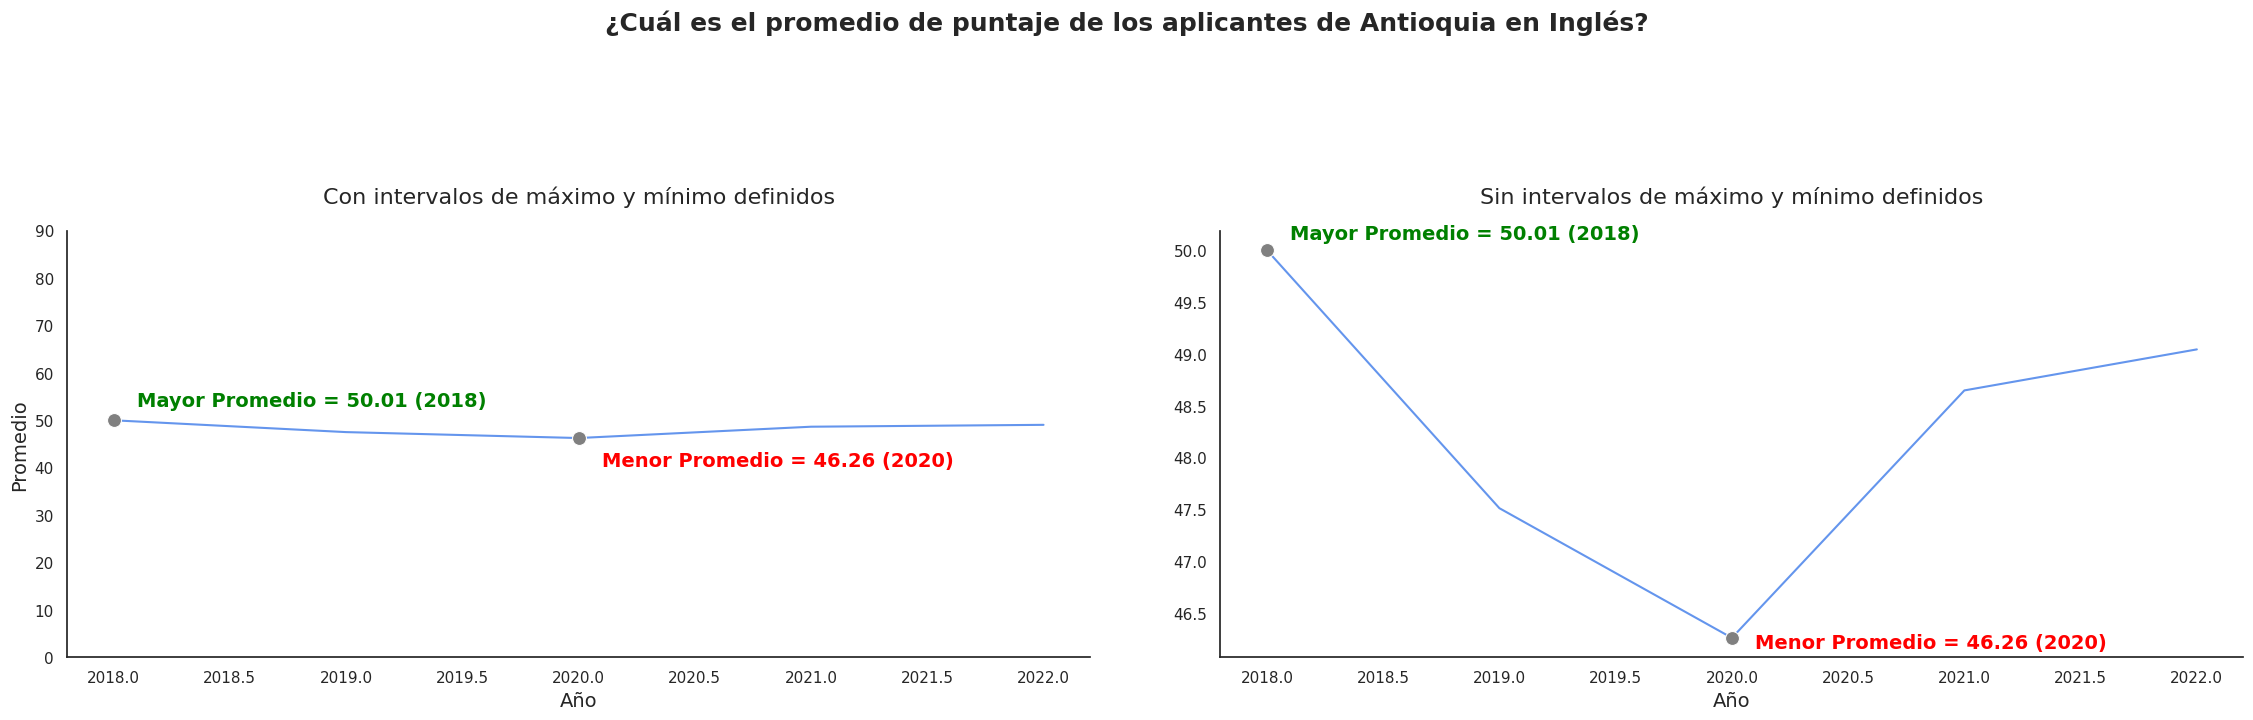

In [ ]:
#@title
## Configurando el gráfico con parámetros que potencializan la visualización de los datos

# Área de visualización y ocultar los bordes del gráfico excepto las de los ejes X y Y

plt.figure(1, figsize=(24, 8))
custom_params = {"axes.spines.right": False, "axes.spines.top": False}

# Tema más limpio para la visualización con los parámetros previamente descritos
sns.set_theme(context="notebook", style="white", rc=custom_params)

# Ajustando la identidad visual de los gráficos
sns.set_palette("light:#6495ed_r")

# Creando las variables que almacenan los puntajes mínimo y máximo, el array con
# todos los puntajes por año y los puntos que serán destacados por el marcador
nota_min = min(saber_ingles_antioquia["PUNT_INGLES"])
nota_max = max(saber_ingles_antioquia["PUNT_INGLES"])
valores = saber_ingles_antioquia["PUNT_INGLES"].values
puntos_a_marcar = list((valores == nota_min) | (valores == nota_max))

# Añadiendo un título al gráfico
plt.suptitle("¿Cuál es el promedio de puntaje de los aplicantes de Antioquia en Inglés?", size = 18, weight='bold')

## GRÁFICO 01 - DESCRIBIENDO LOS INTERVALOS MÍNIMO Y MÁXIMO DE "Y"

# Definiendo el gráfico 01
plt.subplot(121)

# Plotando el gráfico de línea y seleccionando los puntos de máximo y mínimo
ax = sns.lineplot(data = saber_ingles_antioquia, x = "PERIODO", y = "PUNT_INGLES",
                  marker ="o", markersize = 10, markerfacecolor = "grey",
                  markevery = puntos_a_marcar)

# Añadiendo el subtítulo al gráfico y ocultando las etiquetas de cada eje
plt.title("Con intervalos de máximo y mínimo definidos", fontsize = 16, pad = 20)
plt.ylabel("Promedio", fontsize = 14)
plt.xlabel("Año", fontsize = 14)

# Añadiendo el texto para el mayor y menor promedio y el año en que ocurrieron
for x, y in zip(saber_ingles_antioquia["PERIODO"], saber_ingles_antioquia["PUNT_INGLES"]):
  if y == max(saber_ingles_antioquia["PUNT_INGLES"]):
    ax.text(x = x + 0.1, y = y + 3, s = f"Mayor Promedio = {y:.2f} ({x:})", color = "green",
           weight = "bold", fontsize = 14)
  if y == min(saber_ingles_antioquia["PUNT_INGLES"]):
    ax.text(x = x + 0.1, y = y - 6, s = f"Menor Promedio = {y:.2f} ({x:})", color = "red",
           weight = "bold", fontsize = 14)

# Describiendo el límite mínimo y máximo del eje Y
plt.ylim(0, 90)

## GRÁFICO 02 - SIN DESCRIBIR LOS INTERVALOS MÍNIMO Y MÁXIMO

# Definiendo el gráfico 02
plt.subplot(122)

# Plotando el gráfico de línea y seleccionando los puntos de máximo y mínimo
ax = sns.lineplot(data = saber_ingles_antioquia, x = "PERIODO", y = "PUNT_INGLES",
                  marker ="o", markersize = 10, markerfacecolor = "grey",
                  markevery = puntos_a_marcar)

# Añadiendo el subtítulo al gráfico y ocultando las etiquetas de cada eje
plt.title("Sin intervalos de máximo y mínimo definidos", fontsize = 16, pad = 20)
plt.ylabel("")
plt.xlabel("Año", fontsize = 14)

# Añadiendo el texto para el mayor y menor promedio y el año en que ocurrieron
for x, y in zip(saber_ingles_antioquia["PERIODO"], saber_ingles_antioquia["PUNT_INGLES"]):
  if y == max(saber_ingles_antioquia["PUNT_INGLES"]):
    ax.text(x = x + 0.1, y = y + 0.1, s = f"Mayor Promedio = {y:.2f} ({x:})", color = "green",
           weight = "bold", fontsize = 14)
  if y == min(saber_ingles_antioquia["PUNT_INGLES"]):
    ax.text(x = x + 0.1, y = y - 0.1, s = f"Menor Promedio = {y:.2f} ({x:})", color = "red",
           weight = "bold", fontsize = 14)

# Insertando un espacio entre los gráficos
plt.tight_layout(pad=5)

# Exhibiendo los gráficos
plt.show()



<font color=red size=5> ⚠ ¡CUIDADO! ⚠</font>






> Muchas herramientas tratan de ajustar los valores de **máximo** y **mínimo** para aprovechar la proporción máxima de área escogida para el diseño del gráfico.
>
> En muchos casos, este tipo de comportamiento puede llevarnos a una interpretación equivocada de nuestros datos, haciendo que parezcan más discrepantes de lo que realmente son.

<font color=green size=4> Observaciones e Hipótesis: </font>

---
El gráfico de líneas presenta el promedio del puntaje de inglés en Antioquia.

Podemos destacar dos puntos importantes para analizar la evolución de los promedios durante los años: El **menor promedio** registrado es de **46,26** en el año 2020 y el **mayor promedio** es de **50,01** en el año 2018. La diferencia entre ambos promedios es de aproximadamente **4 puntos**.

Vale la pena verificar si este comportamiento es semejante al de otros departamentos o un caso particular de Antioquia.




---



### <font color=#4b6cd4 size=5>Distribución 🧮</font>


---



Es utilizado cuando queremos entender **cómo las observaciones individuales están distribuídas** dentro de nuestro conjunto de datos.

El tipo puede variar dependiendo de los datos. Por ejemplo:
- ¿Cuántas variables estoy representando?
- ¿Tengo muchas o pocas observaciones?

<font color=green> Visualizaciones más comunes: </font> Histogramas de columnas, líneas y gráficos de dispersión.

#### Histograma de barras

In [ ]:
#@title
# Retirando las edades NaN de la columna EDAD
saber_edad =  saber["EDAD"].dropna()

# Seleccionando el intervalo de las edades de las(os) aplicantes de 15 a 40 años
seleccion = (saber_edad >= 15) & (saber_edad <= 60)
saber_edad = saber_edad[seleccion]

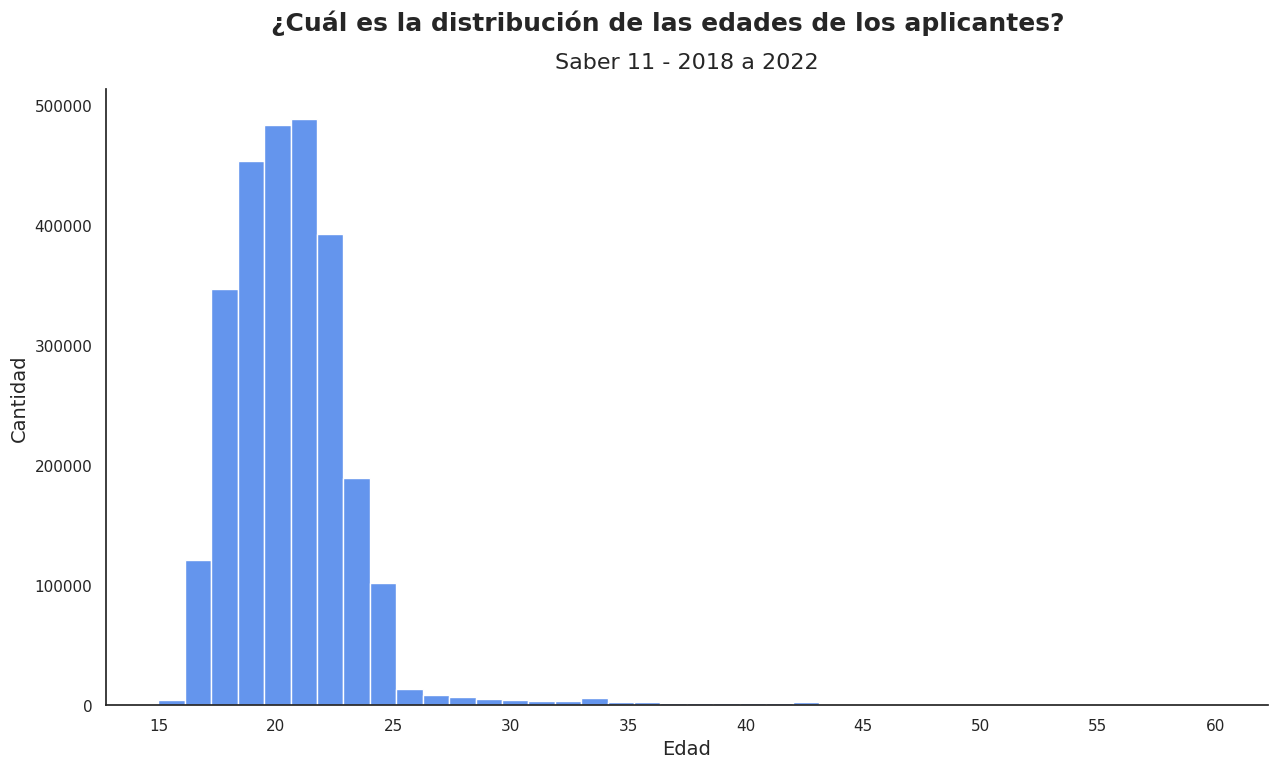

In [ ]:
#@title
## Configurando el gráfico con parámetros que potencializan la visualización de los datos

# Área de visualización y ocultar los bordes del gráfico excepto las de los ejes X y Y

plt.figure(1, figsize=(15, 8))
custom_params = {"axes.spines.right": False, "axes.spines.top": False}

# Tema más limpio para la visualización con los parámetros previamente descritos
sns.set_theme(context="notebook", style="white", rc=custom_params)

# Ajustando la identidad visual de los gráficos
sns.set_palette("light:#6495ed_r")

# Plotando el histograma de columnas y ajustando los puntos del eje X
ax = plt.hist(x = saber_edad, bins = 40)
plt.xticks(list(np.arange(15, 65, step=5)))

# Añadiendo título y subtítulo en nuestro gráfico y el nombre de las etiquetas
plt.suptitle("¿Cuál es la distribución de las edades de los aplicantes?", size = 18, weight='bold')
plt.title("Saber 11 - 2018 a 2022", fontsize = 16, pad = 15)
plt.ylabel("Cantidad", fontsize = 14)
plt.xlabel("Edad", fontsize = 14)

# Oculta las informaciones en la parte superior del gráfico
plt.show()

<font color=green size=4> Observaciones e Hipotesis: </font>

---
El **Saber 11** es un examen de evaluación del aprendizaje de los estudiantes de **Secundaria** de toda Colombia, y también es una herramienta importante para quien desea acceder a las universidades e Instituciones de enseñanza superior de todo el país. Por ello, es esperado que gran parte de los aplicantes se encuentre entre las edades de **18 y 22 años**.

El histograma apunta esta situación, pero podemos también sugerir una atención a los(as) estudiantes **entre los 22 y los 24 años**. Una de las hipótesis es la de que los aplicantes se encuentran buscando una posibilidad de acceso a un segundo pregrado o a un cambio de carrera con el objetivo de alterar el tipo de curso que desean estudiar.



---



### <font color=#da5459 size=5>Relación 🔀</font>


---



Este gráfico se indica cuando estamos interesados en saber **cómo los valores y atributos están relacionándose entre sí**.

Para este tipo, los **gráficos de dispersión** generalmente son usados cuando trazamos la relación entre **dos variables**, y los **gráficos de burbujas** cuando **tres variables** están involucradas.

<font color=green> Visualizaciones más comunes: </font> Gráficos de dispersión y gráficos de burbujas.

#### Gráfico de Dispersión (Scatter plot)

In [ ]:
#@title
# Retirando las notas NaN de las columnas de las notas de Matemática e Ciencias Naturales
saber_mat_cn = saber[["PUNT_MATEMATICAS","PUNT_C_NATURALES"]].dropna()

# Seleccionando todas las notas de Matemática y Ciencias Naturales excepto las que son igual a 0
saber_mat_cn = saber_mat_cn.query("PUNT_MATEMATICAS != 0 & PUNT_C_NATURALES != 0").reset_index(drop = True)



<font color=red size=5> ⚠ ¡CUIDADO! ⚠</font>




> El **gráfico de dispersión** (Scatter Plot) es usado para verificar si existe una **relación entre dos variables numéricas**.
>
> Esto no significa que una variable causa efecto en la otra, solamente si existe una relación y cuál es la intensidad entre esta relación. La relación entre dos variables puede ser **positiva**, **negativa** o **neutra**, **lineal** o **no lineal**.


> Otro punto al que debemos dar especial atención es al  **overplotting**.
>
>De forma resumida, el overplotting se presenta cuando los **datos o labels en una visualización de datos se sobreponen**, tornando dificil notar cada observación de los datos individualmente en la visualización. Este normalmente acontece cuando tenemos un **gran número de observaciones** o un **número restringido de valores únicos** en nuestro dataset.

In [ ]:
#@title
# Seleccionando una muestra aleatoria de 800 puntajes de nuestro DataFrame, para evitar el overplotting
saber_mat_cn = saber_mat_cn.sample(n=800)

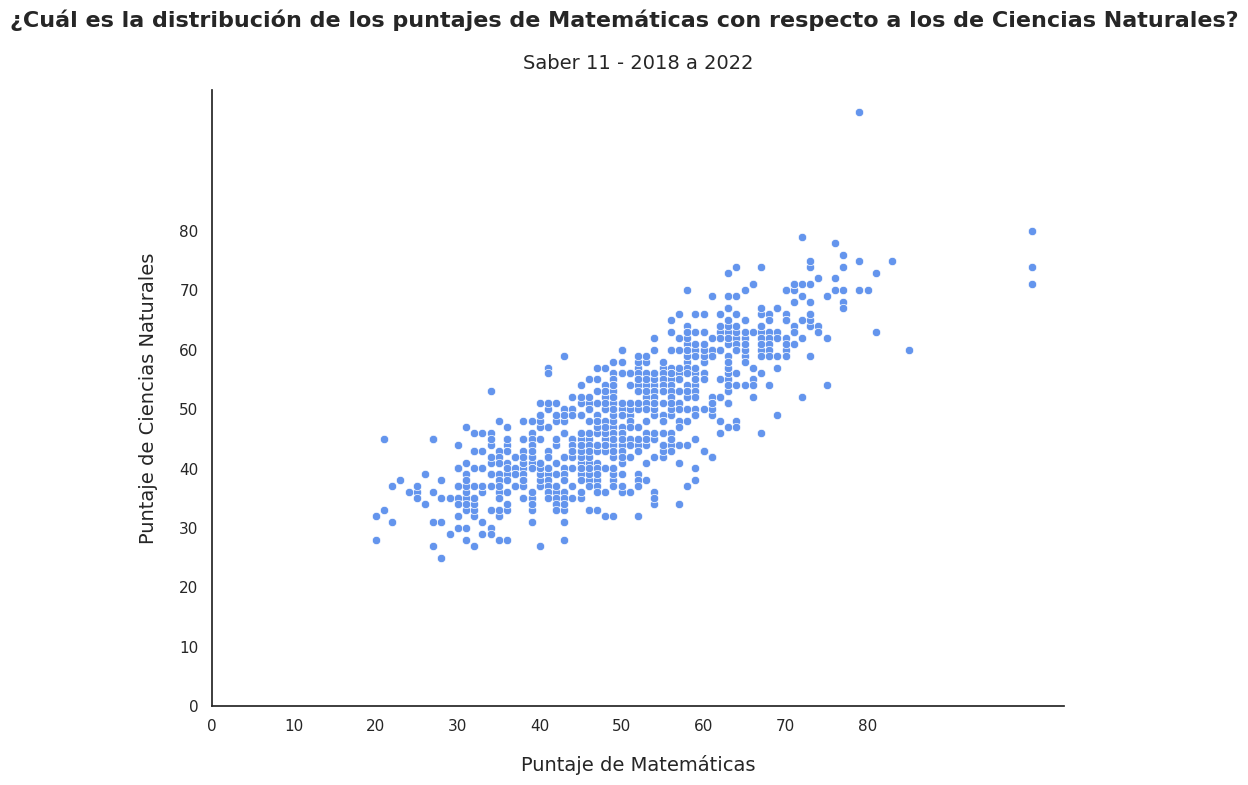

In [ ]:
#@title
## Configurando el gráfico con parámetros que potencializan la visualización de los datos

# Área de visualización y ocultar los bordes del gráfico excepto las de los ejes X y Y

plt.figure(1, figsize=(11, 8))
custom_params = {"axes.spines.right": False, "axes.spines.top": False}

# Tema más limpio para la visualización con los parámetros previamente descritos
sns.set_theme(context="notebook", style="white", rc=custom_params)

# Ajustando la identidad visual de los gráficos
sns.set_palette("light:#6495ed_r")

# Plotando el gráfico de dispersión con la muestra de puntajes escogidos aleatoriamente
ax = sns.scatterplot(data = saber_mat_cn, x = "PUNT_MATEMATICAS", y = "PUNT_C_NATURALES")

# Añadiendo título y subtítulo en nuestro gráfico y el nombre de las etiquetas
plt.suptitle("¿Cuál es la distribución de los puntajes de Matemáticas con respecto a los de Ciencias Naturales?", size = 16, weight='bold')
plt.title("Saber 11 - 2018 a 2022", fontsize = 14, pad = 15)
plt.ylabel("Puntaje de Ciencias Naturales", fontsize = 14, labelpad = 15)
plt.xlabel("Puntaje de Matemáticas", fontsize = 14, labelpad = 15)

# Describiendo el límite mínimo y máximo del eje x y y
plt.xticks(list(np.arange(0, 90, step=10)))
plt.yticks(list(np.arange(0, 90, step=10)))

# Oculta las informaciones en la parte superior del gráfico
plt.show()

<font color=green size=4> Observaciones e Hipótesis: </font>

---

Si observamos el gráfico de dispersión de los puntajes de **Matemáticas** y **Ciencias Naturales**, podemos notar cierta semejança entre estos. Cuando la nota de Matemáticas **aumenta**, la nota de Ciencias tiende a **subir**, y cuando la nota de Matemáticas **disminuye**, la nota de Ciencias tiende a **bajar**.

Luego, podemos inferir que la relación entre las variables es **positiva**.

#### Gráfico de Burbujas

In [ ]:
#@title
# Retirando los puntajes NaN de las columnas seleccionadas
columnas = ["DEPARTAMENTO", "EDAD", "PUNT_MATEMATICAS","PUNT_LECTURA_CRITICA", "PUNT_SOCIALES_CIUDADANAS"]
saber_mat_es_soc = saber[columnas].dropna()

# Seleccionando todas las notas de Matemáticas, Lectura crítica y Sociales excepto las de valor 0
saber_mat_es_soc = saber_mat_es_soc.query("PUNT_MATEMATICAS != 0 & PUNT_LECTURA_CRITICA != 0 & PUNT_SOCIALES_CIUDADANAS != 0").reset_index(drop = True)

# Agrupando los datos por departamento y edad de los aplicantes
saber_mat_es_soc = saber_mat_es_soc.groupby(["DEPARTAMENTO", "EDAD"]).aggregate("mean")

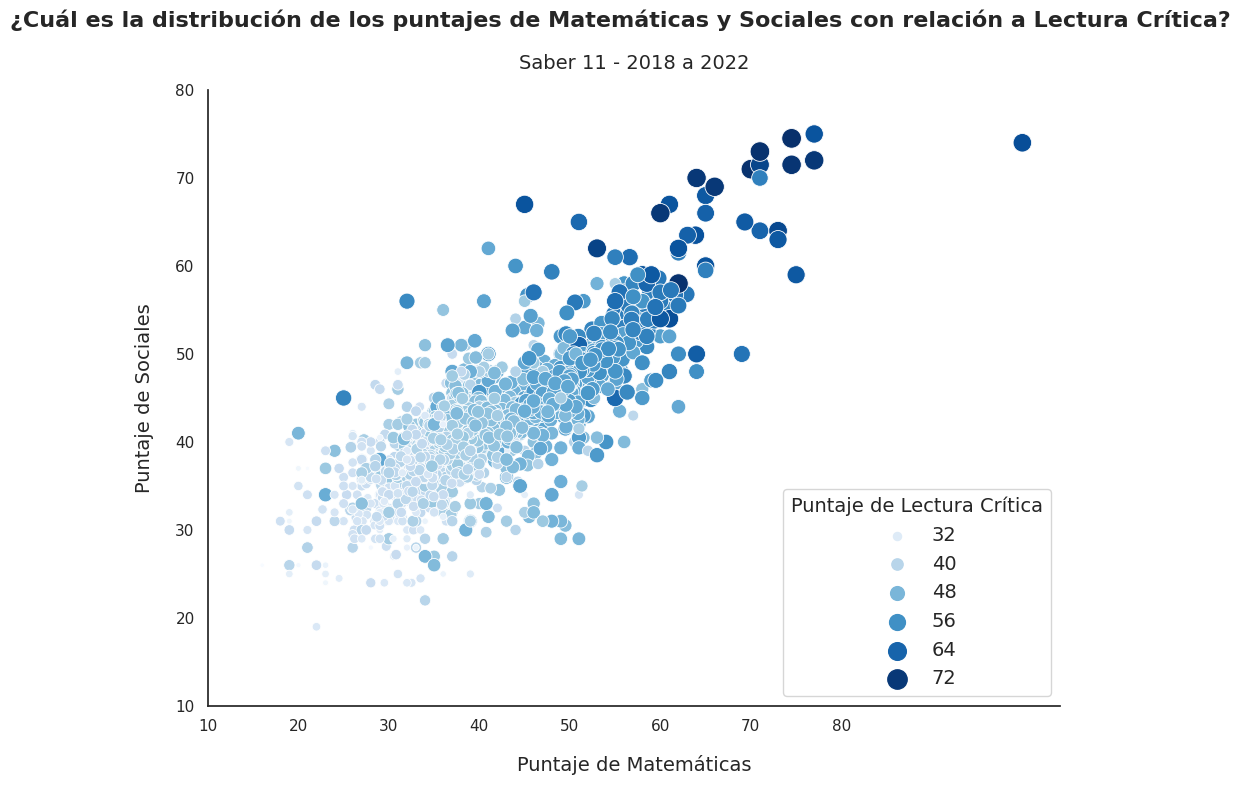

In [ ]:
#@title
## Configurando el gráfico con parámetros que potencializan la visualización de los datos

# Área de visualización y ocultar los bordes del gráfico excepto las de los ejes X y Y
plt.figure(1, figsize=(11, 8))
custom_params = {"axes.spines.right": False, "axes.spines.top": False}

# Tema más limpio para la visualización con los parámetros previamente descritos
sns.set_theme(context="notebook", style="white", rc=custom_params)

# Plotando el gráfico de burbujas con las notas de Lectura Crítica como el tamaño de las burbujas
ax = sns.scatterplot(data = saber_mat_es_soc, x = "PUNT_MATEMATICAS", y = "PUNT_SOCIALES_CIUDADANAS",
                     size = "PUNT_LECTURA_CRITICA", hue = "PUNT_LECTURA_CRITICA", sizes=(10, 200),
                     palette = "Blues")

# Añadiendo título e subtítulo em nosso gráfico e o nome dos labels
plt.suptitle("¿Cuál es la distribución de los puntajes de Matemáticas y Sociales con relación a Lectura Crítica?", size = 16, weight='bold')
plt.title("Saber 11 - 2018 a 2022", fontsize = 14, pad = 15)
plt.ylabel("Puntaje de Sociales", fontsize = 14, labelpad = 15)
plt.xlabel("Puntaje de Matemáticas", fontsize = 14, labelpad = 15)
ax.legend(loc = 'lower right', title='Puntaje de Lectura Crítica', title_fontsize  = 14, fontsize = 14)

# Describiendo el límite mínimo y máximo de los ejes X y Y
plt.xticks(list(np.arange(10, 90, step=10)))
plt.yticks(list(np.arange(10, 90, step=10)))

# Oculta las informaciones en la parte superior del gráfico
plt.show()

<font color=green size=4> Observaciones e Hipótesis: </font>

---

Si observamos el gráfico de dispersión del promedio de puntajes de **Matemáticas**, **Sociales** y **Lectura Crítica**, a principio es posible notar una tendencia clara entre estos.

Así, podemos afirmar que la relación entre las variables aparentemente es **positiva**.



---


### <font color=#9c82b6 size=5>Composición 📦</font>


---


Es utilizado cuando queremos saber **como los datos se componen**, o sea, cuáles características generales están presentes en el conjunto de datos.

Existen algunas variaciones dependiendo de los datos. Por ejemplo:
- ¿Nuestros datos son dinámicos (cambian con el tiempo)?
  - ¿Cuántos períodos de tiempo tenemos?
- En datos estáticos, ¿Tenemos valores que son acumulados?

<font color=green> Visualizaciones más comunes: </font> Gráficos de columnas apiladas, de área y de pizza.

#### Gráfico de Pizza

In [ ]:
#@title
# Generando un DataFrame con el nombre de los estados ordenados con la cantidad de aplicantes
saber_ct = pd.DataFrame({"DEPTO": saber["DEPARTAMENTO"].value_counts().index,
                         "CT": saber["DEPARTAMENTO"].value_counts().values})

# Renombrando todos los departamentos que no pertenecen a las principales sedes como 'Otros'
saber_ct.loc[saber_ct["CT"] < 120000, "DEPTO"] = 'Otros'

# Generando el gráfico de pizza con las principales sedes en relación a toda Colombia
fig = px.pie(saber_ct, values="CT", names='DEPTO', title='Proporción de aplicantes en Colombia (en %)',
             width=700, height=525, color = 'DEPTO',
             color_discrete_map={"ANTIOQUIA": "#83aaf0",
                                 "BOGOTA": "#a8c3f2",
                                 "VALLE": "#cddbf3",
                                 "Otros": "#f3f3f4"})
# Escribiendo los labels y los porcentajes
fig.update_traces(textposition='inside', textinfo='percent+label',
                  marker=dict(line=dict(color='#FFFFFF', width=1)))

# Ocultando la leyenda
fig.update(layout_showlegend=False)

<font color=green size=4> Observaciones e hipótesis: </font>

---

Se analizamos los departamentos con más aplicantes, podemos verificar que estos juntos representan **alrededor del 55% de todos(as) los(as) aplicantes** de la prueba saber. Otro factor que llama la atención es que entre los departamentos de **Antioquia, Valle y Bogotá DC** se hallan casi **1/3** de todos(as) los(as) aplicantes de Colombia.

Al igual que con la primera interrogante, sería interesante trazar un paralelo con la población de cada departamento o con el número de estudiantes en estos datos a través de fuentes externas, como el DANE por ejemplo.

#### Barras apiladas

In [ ]:
#@title
# Seleccionado las columnas relevantes para el análisis
saber_situacion = saber[["PERIODO", "FAMI_SITUACIONECONOMICA"]]

# Creando una tabla cruzada con cada situación separada por año
saber_aplicantes = pd.crosstab(index=saber_situacion["PERIODO"], columns=saber_situacion['FAMI_SITUACIONECONOMICA'])
saber_aplicantes

FAMI_SITUACIONECONOMICA,Igual,Mejor,Peor
PERIODO,,,
2018,330992,125800,73643
2019,322524,133690,72123
2020,291475,87943,109140
2021,316553,108577,90722
2022,303235,121135,83158


#### Barras apiladas (las diferencias absolutas y relativas importan)

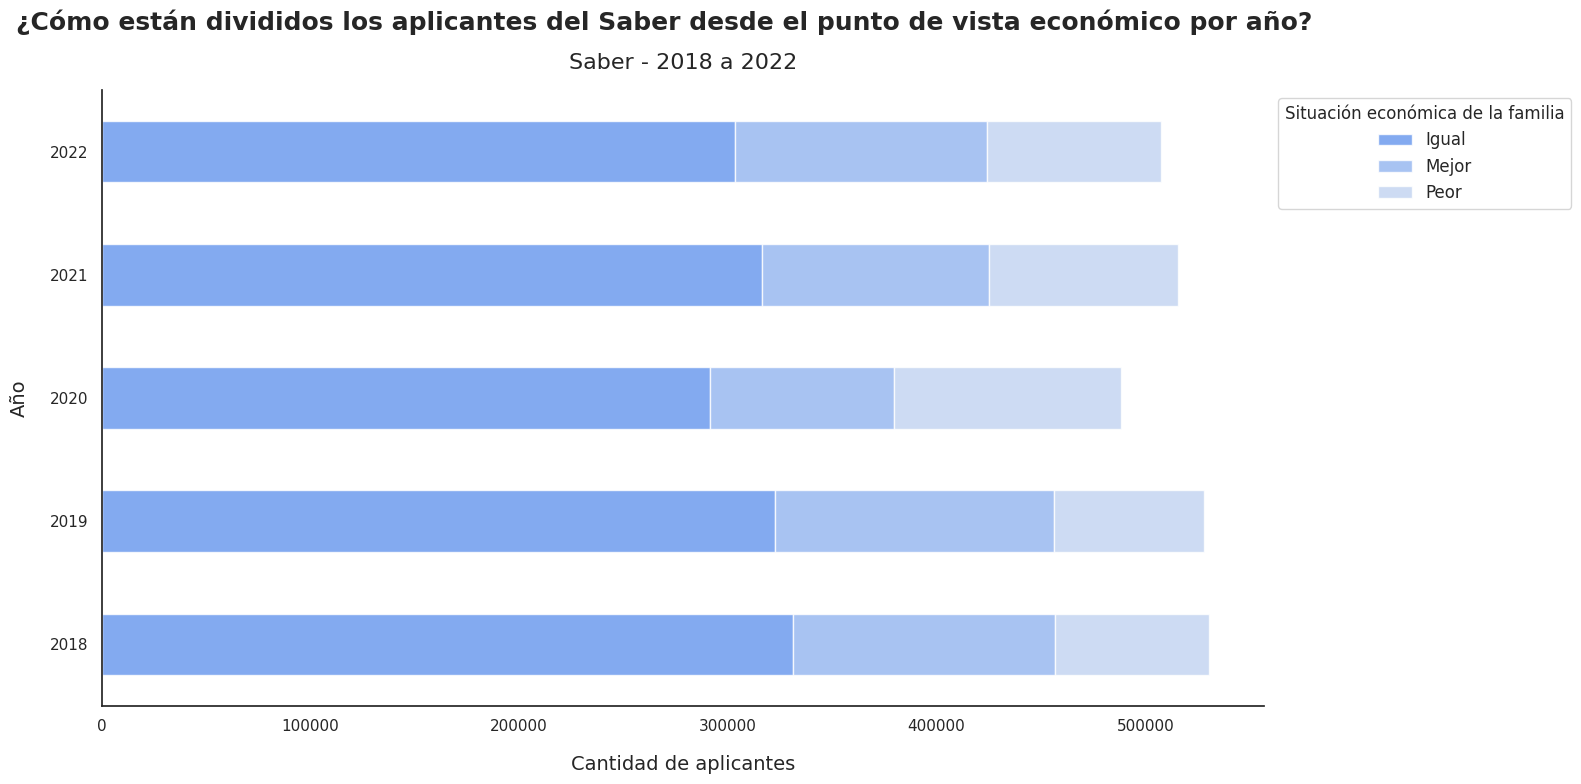

In [ ]:
#@title
## Configurando el gráfico con parámetros que potencializan la visualización de los datos

# Ocultar los bordes del gráfico excepto las de los ejes X y Y
custom_params = {"axes.spines.right": False, "axes.spines.top": False}

# Tema más limpio para la visualización con los parámetros previamente descritos
sns.set_theme(context="notebook", style="white", rc=custom_params)

# Ajustando la identidad visual de los gráficos
sns.set_palette("light:#6495ed_r", 4)

# Plotando el gráfico de barras apiladas y ajustando la leyenda
ax = saber_aplicantes.plot(kind='barh', stacked = True, figsize= (15, 8), alpha  = 0.8)
ax.legend(bbox_to_anchor=(1.005, 1),title='Situación económica de la familia', title_fontsize  = 12, fontsize = 12)

# Añadiendo título y subtítulo en nuestro gráfico
plt.suptitle("¿Cómo están divididos los aplicantes del Saber desde el punto de vista económico por año?", size = 18, weight='bold')
plt.title("Saber - 2018 a 2022", fontsize = 16, pad = 15)
plt.ylabel("Año", fontsize = 14, labelpad = 15)
plt.xlabel("Cantidad de aplicantes", fontsize = 14, labelpad = 15)

# Oculta las informaciones en la parte superior del gráfico
plt.show()

<font color=green size=4> Observaciones e hipótesis: </font>

---
A través del gráfico de barras apiladas, podemos observar las relaciones **absolutas** (cantidad de aplicantes por año) y **relativas** (situación económica de las familias) de los(as) aplicantes de la prueba Saber dentro del período comprendido entre 2018 y 2022. Podemos notar que la situación *Igual* predomina en los datos durante cada año.

Entretanto, el gráfico más adecuado para conocer la relación entre las situaciones y la proporción de estas, para cada año, es el gráfico de barras 100% apiladas, que veremos a continuación.

#### Barras 100% apiladas

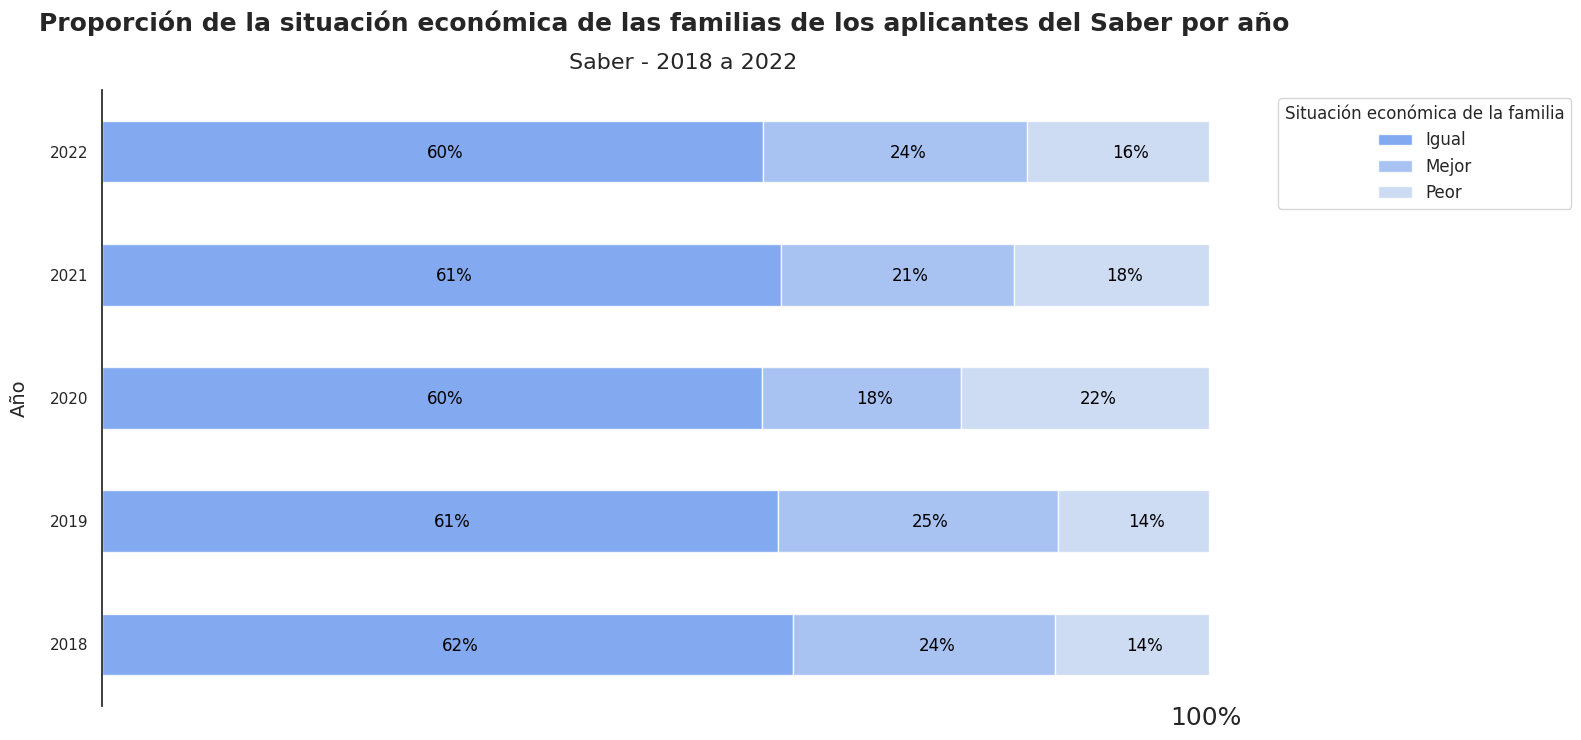

In [ ]:
#@title
## Configurando el gráfico con parámetros que potencializan la visualización de los datos

# Ocultar los bordes del gráfico excepto las de los ejes  Y
custom_params = {"axes.spines.right": False, "axes.spines.top": False,
                 "axes.spines.bottom": False}

# Tema más limpio para la visualización con los parámetros previamente descritos
sns.set_theme(context="notebook", style="white", rc=custom_params)

# Ajustando la identidad visual de los gráficos
sns.set_palette("light:#6495ed_r", 4)

# Creando una tabla cruzada con cada situación separada por año
saber_aplicantes_prop = pd.crosstab(index=saber_situacion["PERIODO"], columns=saber_situacion['FAMI_SITUACIONECONOMICA'],
                               normalize='index')

# Plotando el gráfico de barras 100% apiladas y ajustando la leyenda
ax = saber_aplicantes_prop.plot(kind='barh', stacked=True, figsize= (15, 8), alpha  = 0.8)
ax.legend(bbox_to_anchor=(1.005, 1), title='Situación económica de la familia', title_fontsize  = 12, fontsize = 12)
ax.set_xticklabels([])

# Añadiendo título e subtítulo a nuestro gráfico
plt.suptitle("Proporción de la situación económica de las familias de los aplicantes del Saber por año",
             size = 18, weight='bold')
plt.title("Saber - 2018 a 2022", fontsize = 16, pad = 15)
plt.ylabel("Año", fontsize = 14, labelpad = 15)
plt.xlabel("100%", fontsize = 18, labelpad = 15)

# Ajustando la posición del '100%' en el eje x
ax.xaxis.set_label_coords(0.95, 0)

# Añadiendo los porcentajes en cada barra
for pos, valor in enumerate([*saber_aplicantes.index.values]):
    for (proporcion, count, pos_y) in zip(saber_aplicantes_prop.loc[valor],
                                          saber_aplicantes.loc[valor],
                                          saber_aplicantes_prop.loc[valor].cumsum()):
      if(count != 0):
        plt.text(x = (pos_y - proporcion) + (proporcion / 2) - 0.005,
                y = pos - 0.05,
                s = f'{(proporcion * 100):.0f}%',
                color="black", fontsize=12)

<font color=green size=4> Observaciones e hipótesis: </font>

---

Ahora, con el gráfico de barras 100% apiladas, lo que se destaca en nuestros datos son las **proporciones relativas** en cada año.

Es posible notar que en el año 2020, **más del 20% de aplicantes** manifestaron que la situación económica de las familias había empeorado.



---

## Links Útiles

*   [Infogram | Cómo elegir el gráfico correcto para tus datos](https://infogram.com/es/pagina/elige-el-grafico-correcto-visualizacion-datos)
*   [Biuwer | Cómo elegir el gráfico adecuado para tus datos? (en inglés y español)](https://biuwer.com/es/blog/como-elegir-el-grafico-adecuado-para-tus-datos/)
*   [Data Viz Project | Colección de visualizaciones de datos (en inglés)](https://datavizproject.com/)
*   [From data to Viz | Encuentra el gráfico que necesitas (en inglés)](https://www.data-to-viz.com/)
*   [El Catálogo de visualización de Datos (en inglés, español y otros idiomas)](https://datavizcatalogue.com/ES/)
*   [DisplayR Blog | ¿Qué es el Overplotting? (en inglés)](https://www.displayr.com/what-is-overplotting/)

